In [1]:
# 建议在 Jupyter/终端中选用 conda 环境: conda activate ecx（已配置 JAX）
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
import jax
# Use double precision, important for stability, yet slower
# We may not use this when training the neural networks if it is costly
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import haiku as hk 
import optax
import matplotlib.pyplot as plt
import time
import numpy as np
from scipy.stats import gaussian_kde
colors = [
    "royalblue", "green", "orange", "red", "navy", "brown", "teal", "pink", "gray"
]

def set_static_styles():
    plt.rcParams.update({
        'axes.titlesize': 20,
        'axes.labelsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 14,
        'lines.linewidth': 2,
        'lines.markersize': 6,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'New Century Schoolbook', 'Century Schoolbook L', 'Utopia', 'ITC Bookman', 'Bookman', 'Nimbus Roman No9 L', 'Palatino', 'Charter', 'serif']
    })

def create_subplots(nrow=1,ncol=1,sharex=False,sharey=False):
    set_static_styles()
    width, height = 8*ncol, 6*nrow
    fig, axs = plt.subplots(nrow, ncol, figsize=(width, height),sharex=sharex,sharey=sharey)
    if nrow*ncol == 1:
        axs = [[axs]]
    elif nrow == 1:
        axs = [axs]
    elif ncol == 1:
        axs = [[ax] for ax in axs]
    return fig, axs

In [ ]:
seed = 0
key = jax.random.PRNGKey(seed)
# wealth grid
na = 100 # number of asset grid points
a_min = 0.0 # minimum asset level (borrowing limit)
a_max = 100.0 # maximum asset level
a_grid = jnp.geomspace(0.5,a_max-a_min,na) + a_min - 0.5 # asset grid
# income process
ne = 3 # number of income states
e_grid = jnp.asarray([0.5488, 1.000, 1.8221]) # income states
e_trans = jnp.asarray(
    [[0.6460, 0.3539, 0.0001],
    [0.0304, 0.9392, 0.0304],
    [0.0001, 0.3539, 0.6460]]) # income transition matrix
# compute the stationary distribution of income
A = jnp.transpose(e_trans) - jnp.eye(ne)
A = jnp.vstack([A, jnp.ones(ne)])
b = jnp.zeros(ne + 1)
b = b.at[-1].set(1.0)
e_dist_stationary = jnp.linalg.lstsq(A, b, rcond=None)[0]
e_mean = jnp.sum(e_dist_stationary * e_grid)
e_grid = e_grid / e_mean # normalize mean income to 1
a_dist = jnp.repeat(a_grid, ne).reshape(na,ne) # initial wealth distribution
e_dist = jnp.tile(e_grid, na).reshape(na,ne) # initial income distribution
# TFP shock process
nz = 5 # number of TFP states
z_grid = jnp.asarray([0.9139, 0.9560, 1.0000, 1.0460, 1.0942]) # TFP states
z_trans = jnp.asarray(
    [[0.8478, 0.1522, 0.0000, 0.0000, 0.0000],
    [0.0195, 0.8962, 0.0843, 0.0000, 0.0000],
    [0.0000, 0.0427, 0.9147, 0.0427, 0.0000],
    [0.0000, 0.0000, 0.0843, 0.8962, 0.0195],
    [0.0000, 0.0000, 0.0000, 0.1522, 0.8478]]) # TFP transition matrix
# model parameters
beta = 0.95 # discount factor
sigma = 1 # relative risk aversion
alpha = 0.36 # capital share
delta = 0.025 # depreciation rate
trunc_eps = 1e-3 # truncation error for infinite horizon problem
min_c = 1e-3 # minimum consumption to avoid numerical issues
T = jnp.floor(jnp.log(trunc_eps) / jnp.log(beta)).astype(int) # time horizon for finite horizon problem
@jax.jit
def utility(c,sigma):
    return jax.lax.cond(
        sigma == 1.0,
        lambda : jnp.log(c),
        lambda : c**(1.0 - sigma) / (1.0 - sigma)
    )

## Krusell–Smith 验证：计划与记号

下列条目供你核对 **KS 模型设定** 是否与论文/你的目标一致（确认后可只跑后面代码单元）。

| 项目 | 本 notebook 中的设定 |
|------|----------------------|
| **生产技术** | Cobb–Douglas，$Y_t=z_t K_t^{\alpha}L^1$，$L=1$；全要素生产率 $z_t$ 为有限状态马尔可夫，网格 `z_grid`，转移 `z_trans`。 |
| **要素价格** | $r_t=\alpha z_t K_t^{\alpha-1}-\delta$，$w_t=(1-\alpha) z_t K_t^{\alpha}$（边际产出）。个体劳动效率 $e$ 与 `validate_ks` 稳态块一致：劳动收入为 $e\cdot w_t$。 |
| **个体问题** | 资产 $a\ge 0$，预算 $(1+r_t)a+e w_t-c=a'$；异质性 $e$ 转移 `e_trans`。 |
| **理性预期 / KS 外循环** | 对每一 $z$，感知运动法则（PLM）$\log K_{t+1}=a_z\log K_t+b_z$。外循环更新 $(a_z,b_z)$；内层在给定 PLM 下对 $(a,e,z,K)$ 做值函数迭代（$K$ 在离散网格上，并对 $K'$ 做一维插值）。 |
| **回归更新** | 用模拟得到的 $(K_t,z_t,K_{t+1})$ 分 $z$ 做 OLS；系数软更新：$\theta\leftarrow (1-\lambda)\theta+\lambda\hat\theta$，本笔记取 $\lambda=0.2$。 |
| **DSPG (KS environment)** | Same spirit as `main.ipynb`: U-Net maps distribution $\mathbf g$ to consumption by $z$; $(r,w)$ from $(z,K)$ instead of bond clearing; `steady_dist` initializes the network and simulation. |
| **对比图** | 在各自算法得到的策略下，**同一条** $z_t$ 随机路径（固定种子）上模拟 100 期，绘制总资本 $K_t=\sum_{a,e} g_t(a,e)\,a$ 与总消费 $C_t=\sum_{a,e} g_t\,c_t$。 |

**需要你确认的点**：$\beta$、$\alpha$、$\delta$ 是否与 KS 文献一致；$e$ 过程是否采用 KR 的离散化；PLM 是否只对 $K$ 对数线性（不含 $z$ 交互项以外的形式）。若需与某篇论文数值完全一致，可再对齐网格尺寸与外循环容差。


In [3]:
@jax.jit
def iterpolate_nonuniform(x, grids):
    # make x within the grid range
    x = jnp.clip(x, grids[0], grids[-1])
    idx = jnp.searchsorted(grids, x) - 1
    idx = jnp.clip(idx, 0, len(grids)-2)
    x0, x1 = grids[idx], grids[idx+1]
    y0, y1 = idx.astype(int), (idx+1).astype(int)
    w0 = (x1 - x) / (x1 - x0 + 1e-12)
    w1 = 1.0 - w0
    return y0, y1, w0, w1

@jax.jit
def update_V(aidx,V,r,w):
    def loop_e(eidx):
        a, e = a_grid[aidx], e_grid[eidx]
        wealth = (1+r)*a + e*w
        def find_all_v(c):
            next_wealth = wealth - c
            y0, y1, w0, w1 = iterpolate_nonuniform(next_wealth, a_grid)
            expected_future_V = jnp.sum((V[y0]*w0 + V[y1]*w1)*e_trans[eidx])
            return utility(c,sigma) + beta * expected_future_V
        cgrid = jnp.linspace(1e-3, wealth - a_min, 8192)
        expected_Vs = jax.vmap(find_all_v)(cgrid)
        expected_V = jnp.max(expected_Vs)
        opt_c = cgrid[jnp.argmax(expected_Vs)]
        return expected_V, opt_c
    return jax.vmap(loop_e)(jnp.arange(ne))

def vfi(r,w):
    V = jnp.zeros((na,ne))
    while True:
        V_new,opt_c = jax.vmap(update_V,in_axes=(0,None,None,None))(jnp.arange(na),V,r,w)
        if jnp.max(jnp.abs(V_new - V)) < 1e-7:
            break
        V = V_new
    return V, opt_c

@jax.jit
def state_transit(opt_c,g,r,w):
    def loop_a(aidx):
        def loop_e(eidx):
            a, e = a_grid[aidx], e_grid[eidx]
            wealth = (1+r)*a + e*w
            c = opt_c[aidx,eidx]
            next_wealth = wealth - c
            y0, y1, w0, w1 = iterpolate_nonuniform(next_wealth, a_grid)
            g_new = jnp.zeros((na,ne))
            g_new = g_new.at[y0].set(g[aidx,eidx]*w0*e_trans[eidx])
            g_new = g_new.at[y1].set(g[aidx,eidx]*w1*e_trans[eidx])
            return g_new
        return jax.vmap(loop_e)(jnp.arange(ne))
    return jax.vmap(loop_a)(jnp.arange(na)).sum(axis=(0,1))

@jax.jit
def compute_stationary_dis(opt_c,r,w):
    g = jnp.full((na,ne),1.0/(na*ne))
    def step(g,_):
        return state_transit(opt_c,g,r,w), g
    return jax.lax.scan(step,g,length=2000)


# outer loop: binary search for aggregate capital K
left, right = 0, 20
while left < right:
    mid = (left + right) / 2.0
    r = alpha * mid**(alpha-1) - delta
    w = (1 - alpha) * mid**alpha
    V,opt_c = vfi(r,w)
    g,g_all = compute_stationary_dis(opt_c,r,w)
    K = jnp.sum(g*a_dist)
    
    if K <= mid:
        right = mid
    else:
        left = mid
    print(f"K: {mid:.6f}, capital err: {(K-mid)/mid:.2%}")
    if jnp.abs(K - mid)/mid < 1e-2:
        break
steady_K = mid
steady_dist = g
print(f"Aggregate capital at equilibrium: {steady_K:.3E}")

K: 10.000000, capital err: 893.68%
K: 15.000000, capital err: -94.38%
K: 12.500000, capital err: -84.80%
K: 11.250000, capital err: 24.35%
K: 11.875000, capital err: -74.54%
K: 11.562500, capital err: -61.23%
K: 11.406250, capital err: -45.53%
K: 11.328125, capital err: -27.48%
K: 11.289062, capital err: -8.98%
K: 11.269531, capital err: 5.14%
K: 11.279297, capital err: -3.06%
K: 11.274414, capital err: 2.87%
K: 11.276855, capital err: 0.14%
Aggregate capital at equilibrium: 1.128E+01


In [27]:
# --- Krusell–Smith: PLM 外循环 + 内层 VFI（状态含 z 与 K）---
# K 网格：围绕无总风险稳态资本 steady_K
nK = 11
K_lo = float(steady_K) * 0.55
K_hi = float(steady_K) * 1.45
K_grid = jnp.geomspace(K_lo, K_hi, nK)

a_plm = jnp.ones(nz)
b_plm = jnp.zeros(nz)
relax_plm = 0.2


@jax.jit
def interp1d_lin(xq, grid, vals):
    xq = jnp.clip(xq, grid[0], grid[-1])
    idx = jnp.searchsorted(grid, xq) - 1
    idx = jnp.clip(idx, 0, grid.shape[0] - 2)
    x0, x1 = grid[idx], grid[idx + 1]
    w1 = (xq - x0) / (x1 - x0 + 1e-12)
    w0 = 1.0 - w1
    return w0 * vals[idx] + w1 * vals[idx + 1]


@jax.jit
def interp2d_aK(V_slice, ap, Kp):
    """V_slice: (na, nK), 在 (ap, Kp) 双线性插值。"""
    ap = jnp.clip(ap, a_grid[0], a_grid[-1])
    Kp = jnp.clip(Kp, K_grid[0], K_grid[-1])
    ia = jnp.searchsorted(a_grid, ap) - 1
    ia = jnp.clip(ia, 0, na - 2)
    ik = jnp.searchsorted(K_grid, Kp) - 1
    ik = jnp.clip(ik, 0, nK - 2)
    a0, a1 = a_grid[ia], a_grid[ia + 1]
    k0, k1 = K_grid[ik], K_grid[ik + 1]
    wa1 = (ap - a0) / (a1 - a0 + 1e-12)
    wa0 = 1.0 - wa1
    wk1 = (Kp - k0) / (k1 - k0 + 1e-12)
    wk0 = 1.0 - wk1
    v00 = V_slice[ia, ik]
    v01 = V_slice[ia, ik + 1]
    v10 = V_slice[ia + 1, ik]
    v11 = V_slice[ia + 1, ik + 1]
    v0 = wk0 * v00 + wk1 * v01
    v1 = wk0 * v10 + wk1 * v11
    return wa0 * v0 + wa1 * v1


@jax.jit
def expected_V_next(ap, eidx, zidx, V, Kp):
    ep = jnp.arange(ne)
    zp = jnp.arange(nz)

    def inner_ep(e):
        vals = jax.vmap(lambda zpi: interp2d_aK(V[:, e, zpi, :], ap, Kp))(zp)
        return jnp.dot(z_trans[zidx], vals)

    return jnp.sum(e_trans[eidx, ep] * jax.vmap(inner_ep)(ep))


@jax.jit
def update_V_ks(aidx, V, zidx, kidx, a_plm, b_plm):
    def loop_e(eidx):
        K = K_grid[kidx]
        z = z_grid[zidx]
        r = alpha * z * K ** (alpha - 1.0) - delta
        w = (1.0 - alpha) * z * K ** alpha
        a = a_grid[aidx]
        e = e_grid[eidx]
        wealth = (1.0 + r) * a + e * w
        logKp = a_plm[zidx] * jnp.log(K) + b_plm[zidx]
        Kp = jnp.exp(logKp)
        Kp = jnp.clip(Kp, K_grid[0], K_grid[-1])

        def find_all_v(c):
            ap = wealth - c
            ap = jnp.clip(ap, a_min, a_grid[-1])
            ev = expected_V_next(ap, eidx, zidx, V, Kp)
            return utility(c, sigma) + beta * ev

        cgrid = jnp.linspace(min_c, wealth - a_min, 4096)
        vals = jax.vmap(find_all_v)(cgrid)
        best = jnp.argmax(vals)
        return vals[best], cgrid[best]

    return jax.vmap(loop_e)(jnp.arange(ne))


@jax.jit
def vfi_ks_one_step(V, a_plm, b_plm):
    def one_ik(iz, ik):
        return jax.vmap(lambda ai: update_V_ks(ai, V, iz, ik, a_plm, b_plm))(jnp.arange(na))

    def one_iz(iz):
        return jax.vmap(lambda ik: one_ik(iz, ik))(jnp.arange(nK))

    V_part, c_part = jax.vmap(one_iz)(jnp.arange(nz))
    # (nz, nK, na, ne) -> (na, ne, nz, nK)
    return V_part.transpose(2, 3, 0, 1), c_part.transpose(2, 3, 0, 1)


def vfi_ks(a_plm, b_plm, max_iter=4000, tol=1e-6):
    V = jnp.zeros((na, ne, nz, nK))
    for it in range(max_iter):
        V_new, opt_c = vfi_ks_one_step(V, a_plm, b_plm)
        diff = jnp.max(jnp.abs(V_new - V))
        V = V_new
        if float(diff) < tol:
            break
    return V, opt_c


@jax.jit
def state_transit_ks(opt_c_zk, g, r, w):
    """opt_c_zk: (na, ne), 当期价格 r,w 标量。"""

    def loop_a(aidx):
        def loop_e(eidx):
            a, e = a_grid[aidx], e_grid[eidx]
            wealth = (1.0 + r) * a + e * w
            c = opt_c_zk[aidx, eidx]
            c = jnp.minimum(c, wealth - a_min - min_c)
            next_wealth = wealth - c
            y0, y1, w0, w1 = iterpolate_nonuniform(next_wealth, a_grid)
            g_new = jnp.zeros((na, ne))
            g_new = g_new.at[y0].set(g[aidx, eidx] * w0 * e_trans[eidx, :])
            g_new = g_new.at[y1].set(g[aidx, eidx] * w1 * e_trans[eidx, :])
            return g_new

        return jax.vmap(loop_e)(jnp.arange(ne))

    return jax.vmap(loop_a)(jnp.arange(na)).sum(axis=(0, 1))


def ks_simulate_for_regression(opt_c, key, n_steps=6000, burn=1500):
    g = steady_dist / (jnp.sum(steady_dist) + 1e-15)

    def step(carry, _):
        g, zidx, key = carry
        K = jnp.sum(g * a_dist)
        ik = jnp.argmin(jnp.abs(K_grid - K))
        z = zidx
        r = alpha * z_grid[z] * K ** (alpha - 1.0) - delta
        w = (1.0 - alpha) * z_grid[z] * K ** alpha
        oc = opt_c[:, :, z, ik]
        g_new = state_transit_ks(oc, g, r, w)
        g_new = g_new / (jnp.sum(g_new) + 1e-15)
        Kp = jnp.sum(g_new * a_dist)
        key, k1 = jax.random.split(key)
        zidx = jax.random.choice(k1, nz, p=z_trans[zidx])
        return (g_new, zidx, key), (jnp.log(K + 1e-12), jnp.log(Kp + 1e-12), z)

    key, k0 = jax.random.split(key)
    z0 = jax.random.choice(k0, nz, p=jnp.ones(nz) / nz)
    (g, _, key), rec = jax.lax.scan(step, (g, z0, key), None, length=n_steps)
    logK, logKp, zz = rec[0][burn:], rec[1][burn:], rec[2][burn:]
    return logK, logKp, zz


def ks_regress_plm(logK, logKp, z_list):
    """OLS: log K' = b + a log K for each z. Returns (a, b, r2_per_z)."""
    a_new = np.zeros(nz)
    b_new = np.zeros(nz)
    r2_new = np.full(nz, np.nan, dtype=np.float64)
    z_list = np.asarray(z_list)
    logK = np.asarray(logK)
    logKp = np.asarray(logKp)
    for z in range(nz):
        mask = z_list == z
        n_z = int(np.sum(mask))
        if n_z < 30:
            a_new[z], b_new[z] = 1.0, 0.0
            r2_new[z] = np.nan
            continue
        x = logK[mask]
        y = logKp[mask]
        X = np.stack([np.ones_like(x), x], axis=1)
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        b_new[z], a_new[z] = coef[0], coef[1]
        y_hat = X @ coef
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        if ss_tot > 1e-18:
            r2_new[z] = 1.0 - ss_res / ss_tot
        else:
            r2_new[z] = np.nan
    return jnp.asarray(a_new), jnp.asarray(b_new), r2_new


print("KS outer loop: PLM + VFI ...")
key_ks = jax.random.PRNGKey(42)
max_outer = 25
for outer in range(max_outer):
    V_ks, opt_c_ks = vfi_ks(a_plm, b_plm)
    lk, lkp, zz = ks_simulate_for_regression(opt_c_ks, key_ks)
    key_ks, _ = jax.random.split(key_ks)
    ah, bh, r2_ols = ks_regress_plm(lk, lkp, zz)
    a_prev, b_prev = np.asarray(a_plm), np.asarray(b_plm)
    a_plm = jnp.asarray((1.0 - relax_plm) * a_prev + relax_plm * np.asarray(ah))
    b_plm = jnp.asarray((1.0 - relax_plm) * b_prev + relax_plm * np.asarray(bh))
    da = float(np.max(np.abs(a_plm - a_prev)))
    db = float(np.max(np.abs(b_plm - b_prev)))
    r2_parts = [
        f"z{z}={float(r2_ols[z]):.4f}" if np.isfinite(r2_ols[z]) else f"z{z}=nan"
        for z in range(nz)
    ]
    r2_valid = r2_ols[np.isfinite(r2_ols)]
    r2_mean = float(np.mean(r2_valid)) if r2_valid.size else float("nan")
    print(
        f"  outer {outer+1}: max|Δa|={da:.4e}, max|Δb|={db:.4e} | "
        f"OLS R²: mean={r2_mean:.4f} | " + ", ".join(r2_parts)
    )
    if da < 1e-3 and db < 1e-3:
        print("  KS PLM converged.")
        break

print("PLM a_z:", a_plm)
print("PLM b_z:", b_plm)



KS outer loop: PLM + VFI ...
  outer 1: max|Δa|=2.9581e-02, max|Δb|=7.2987e-02 | OLS R²: mean=0.9673 | z0=0.9529, z1=0.9674, z2=0.9785, z3=0.9559, z4=0.9819
  outer 2: max|Δa|=1.5131e-02, max|Δb|=3.5554e-02 | OLS R²: mean=0.9907 | z0=0.9903, z1=0.9849, z2=0.9909, z3=0.9923, z4=0.9950
  outer 3: max|Δa|=9.4669e-03, max|Δb|=2.3838e-02 | OLS R²: mean=0.9935 | z0=0.9933, z1=0.9902, z2=0.9933, z3=0.9961, z4=0.9947
  outer 4: max|Δa|=6.3409e-03, max|Δb|=1.4835e-02 | OLS R²: mean=0.9948 | z0=0.9938, z1=0.9924, z2=0.9948, z3=0.9970, z4=0.9962
  outer 5: max|Δa|=4.3337e-03, max|Δb|=1.1302e-02 | OLS R²: mean=0.9955 | z0=0.9950, z1=0.9934, z2=0.9954, z3=0.9974, z4=0.9965
  outer 6: max|Δa|=3.8081e-03, max|Δb|=9.8956e-03 | OLS R²: mean=0.9958 | z0=0.9951, z1=0.9940, z2=0.9957, z3=0.9977, z4=0.9964
  outer 7: max|Δa|=1.8836e-03, max|Δb|=4.4613e-03 | OLS R²: mean=0.9961 | z0=0.9953, z1=0.9946, z2=0.9961, z3=0.9978, z4=0.9970
  outer 8: max|Δa|=2.1173e-03, max|Δb|=4.6655e-03 | OLS R²: mean=0.9961 | z

In [28]:
# --- DSPG（Krusell–Smith：由 z,K 决定 r,w）---
key = jax.random.PRNGKey(seed + 7)
activation = jax.nn.leaky_relu
pool = hk.AvgPool
diffs = jnp.diff(opt_c, axis=0)
max_diff = jnp.zeros((na, ne))
max_diff = max_diff.at[0, :].set(diffs[0, :])
max_diff = max_diff.at[1:, :].set(diffs)
max_diff *= 3.0
csmp0 = opt_c[0, :]


class DoubleConv(hk.Module):
    def __init__(self, out_channels, name=None):
        super().__init__(name=name)
        self.out_channels = out_channels

    def __call__(self, x):
        x = hk.Conv1D(output_channels=self.out_channels, kernel_shape=3, stride=1, padding="SAME")(x)
        x = activation(x)
        x = hk.Conv1D(output_channels=self.out_channels, kernel_shape=3, stride=1, padding="SAME")(x)
        x = activation(x)
        return x


def forward_fn(g):
    # 加宽 U-Net（C1→C2→C3），提高对分布 \mathbf{g} 的表征能力；原架构通道数为 4
    C1, C2, C3 = 4, 4, 4
    g = g / jnp.sum(g, axis=(1, 2), keepdims=True)
    g = g * na * ne
    x1 = DoubleConv(C1)(g)
    x2 = pool(window_shape=2, strides=2, padding="SAME")(x1)
    x2 = DoubleConv(C2)(x2)
    x3 = pool(window_shape=2, strides=2, padding="SAME")(x2)
    x3 = DoubleConv(C3)(x3)
    y = x3
    y = hk.Conv1DTranspose(output_channels=C2, kernel_shape=3, stride=2, padding="SAME")(y)
    y = y[:, : x2.shape[1], :]
    y = jnp.concatenate([y, x2], axis=-1)
    y = DoubleConv(C2)(y)
    y = hk.Conv1DTranspose(output_channels=C1, kernel_shape=3, stride=2, padding="SAME")(y)
    y = y[:, : x1.shape[1], :]
    y = jnp.concatenate([y, x1], axis=-1)
    y = DoubleConv(C1)(y)
    y = hk.Conv1D(output_channels=ne * nz, kernel_shape=1, stride=1, padding="SAME")(y)
    y = jax.nn.sigmoid(y.reshape(y.shape[0], na, ne, nz))
    c = jnp.zeros((y.shape[0], na + 1, ne, nz))
    c = c.at[:, 0, :, :].set(csmp0[None, :, None] * jnp.ones((y.shape[0], ne, nz)))
    c = c.at[:, 1:, :, :].set(y * max_diff[None, ..., None])
    c = jnp.cumsum(c, axis=1)
    c = c[:, 1:, :, :]
    return c


forward = hk.without_apply_rng(hk.transform(forward_fn))
_key, key = jax.random.split(key)
dummy_g = jnp.ones((2, na, ne))
params = forward.init(_key, dummy_g)

batch_size = 64
epoch = 1000
train_lr = optax.exponential_decay(2e-3, epoch, 0.1)
optimizer = optax.adam(train_lr)
opt_state = optimizer.init(params)


@jax.jit
def update_g(wealth_next_batch, g_batch):
    def loop_B(wealth_next, g):
        def loop_a(aidx):
            def loop_e(eidx):
                next_a = wealth_next[aidx, eidx]
                y0, y1, w0, w1 = iterpolate_nonuniform(next_a, a_grid)
                g_new = jnp.zeros((na, ne))
                enext_prob = e_trans[eidx]
                g_new = g_new.at[y0].set(g[aidx, eidx] * w0 * enext_prob)
                g_new = g_new.at[y1].set(g[aidx, eidx] * w1 * enext_prob)
                return g_new

            return jax.vmap(loop_e)(jnp.arange(ne))

        return jax.vmap(loop_a)(jnp.arange(na))

    return jax.vmap(loop_B)(wealth_next_batch, g_batch).sum(axis=(1, 2))


@jax.jit
def cumulative_utility_loss(params, key, g):
    def step(pack, _):
        g_batch, zidx, discount, key = pack
        c_of_z = forward.apply(params, g_batch)
        c = jax.vmap(lambda idx, y: y[..., idx])(zidx, c_of_z)
        K = jnp.sum(g_batch * a_dist[None, ...], axis=(1, 2))
        z = z_grid[zidx]
        r = alpha * z * K ** (alpha - 1.0) - delta
        w = (1.0 - alpha) * z * K ** alpha
        wealth = (1.0 + r[:, None, None]) * a_dist[None, ...] + e_dist[None, ...] * w[:, None, None]
        c = jnp.minimum(c, wealth - a_min - min_c)
        wealth_next = wealth - c
        g_batch = update_g(wealth_next, g_batch)
        util = jnp.sum(utility(c, sigma) * g_batch, axis=(1, 2)) * discount * (1-beta)
        discount = discount * beta
        _key, key = jax.random.split(key)
        keys = jax.random.split(_key, batch_size)
        zidx = jax.vmap(lambda idx, k: jax.random.choice(k, nz, p=z_trans[idx]))(zidx, keys)
        return (g_batch, zidx, discount, key), util

    key, _key = jax.random.split(key)
    zidx = jax.random.choice(_key, nz, (batch_size,))
    discount = 1.0
    (final_g, _, _, _), utilities = jax.lax.scan(step, (g, zidx, discount, key), None, length=T)
    total_utility = jnp.sum(utilities, axis=0).mean()
    return -total_utility, final_g


@jax.jit
def train_step_2(params, opt_state, key, g0):
    g = g0

    (loss, final_g), grads = jax.value_and_grad(cumulative_utility_loss, has_aux=True)(params, key, g)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    agg_k = jnp.sum(final_g * a_dist[None, ...], axis=(1, 2))
    return params, opt_state, loss, agg_k, final_g


tgts = []
st = time.time()
final_g = jnp.ones((batch_size, na, ne)) * steady_dist[None, ...]
for ep in range(epoch):
    key, _key = jax.random.split(key)
    if ep < 50:
        g0 = jnp.ones((batch_size, na, ne)) * steady_dist[None, ...]
    else:
        g0 = final_g
    params, opt_state, loss, agg_k, final_g = train_step_2(params, opt_state, _key, g0)
    tgts.append(-float(loss))
    if (ep + 1) % 100 == 0 or ep == 0:
        print(f"DSPG epoch {ep+1}/{epoch}, target {-float(loss):.4f}, mean K {float(jnp.mean(agg_k)):.4f}")
et = time.time()
g_steady_nn = jnp.mean(final_g, axis=0)
print(f"DSPG training done in {et - st:.1f}s")

DSPG epoch 1/1000, target 0.6144, mean K 5.9628
DSPG epoch 100/1000, target 0.5496, mean K 9.2487
DSPG epoch 200/1000, target 0.7385, mean K 12.7730
DSPG epoch 300/1000, target 0.7695, mean K 13.3741


KeyboardInterrupt: 

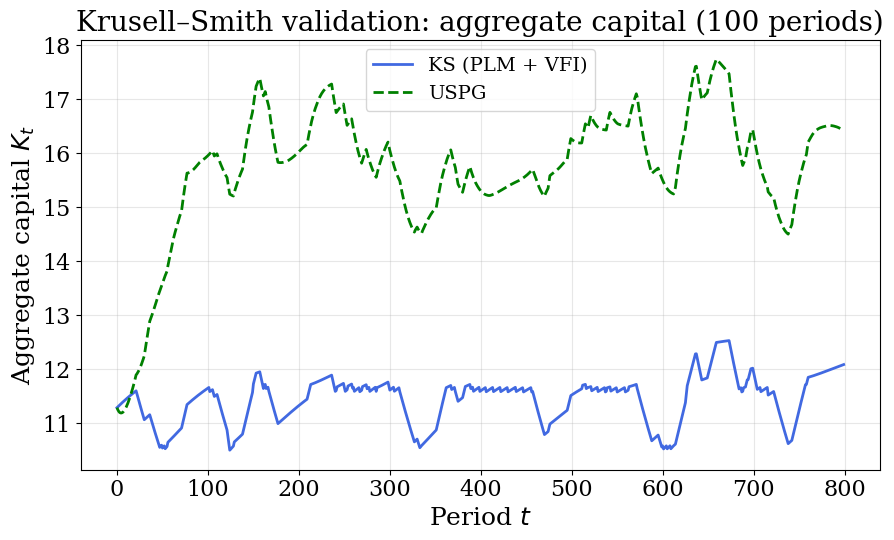

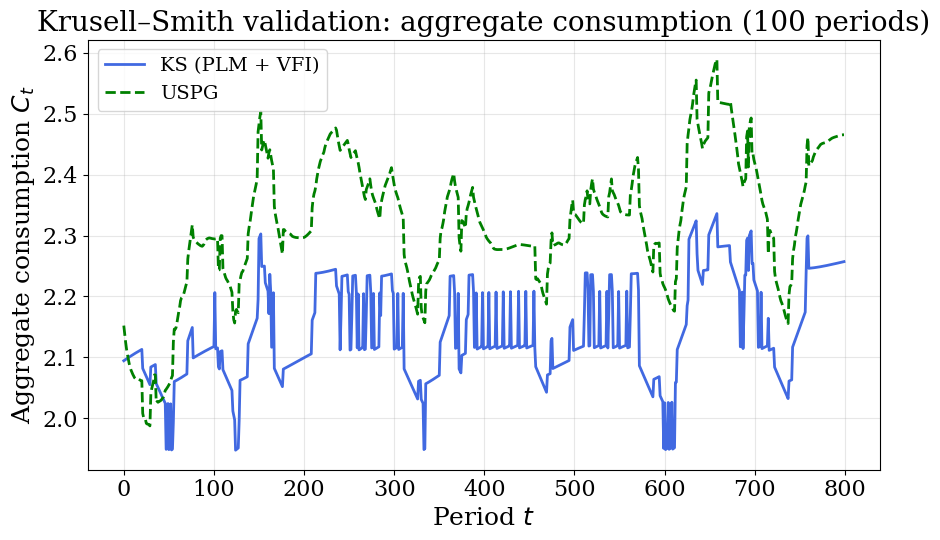

In [21]:
# --- 100 期模拟：同一条 z 路径下对比 K_t、C_t ---
os.makedirs("figures", exist_ok=True)
sim_T = 800
key_sim = jax.random.PRNGKey(2026)


def z_path_markov(key, length, z0):
    def step(z, k):
        k, kc = jax.random.split(k)
        zn = jax.random.choice(kc, nz, p=z_trans[z])
        return zn, z

    keys = jax.random.split(key, length)
    _, z_seq = jax.lax.scan(step, z0, keys)
    return z_seq


A = jnp.transpose(z_trans) - jnp.eye(nz)
A = jnp.vstack([A, jnp.ones((1, nz))])
b = jnp.zeros(nz + 1)
b = b.at[-1].set(1.0)
z_stat = jnp.linalg.lstsq(A, b, rcond=None)[0]

key_sim, kz0, kpath = jax.random.split(key_sim, 3)
z0 = jax.random.choice(kz0, nz, p=z_stat)
z_seq = z_path_markov(kpath, sim_T, z0)

g0 = steady_dist / (jnp.sum(steady_dist) + 1e-15)


@jax.jit
def scan_ks_path(g0, z_seq, opt_c_ks):
    def step(g, zidx):
        K = jnp.sum(g * a_dist)
        ik = jnp.argmin(jnp.abs(K_grid - K))
        r = alpha * z_grid[zidx] * K ** (alpha - 1.0) - delta
        w = (1.0 - alpha) * z_grid[zidx] * K ** alpha
        oc = opt_c_ks[:, :, zidx, ik]
        C = jnp.sum(g * oc)
        g_new = state_transit_ks(oc, g, r, w)
        g_new = g_new / (jnp.sum(g_new) + 1e-15)
        return g_new, (K, C)

    _, out = jax.lax.scan(step, g0, z_seq)
    return out[0], out[1]


def scan_dspg_path(g0, z_seq, params):
    def step(g, zidx):
        c_all = forward.apply(params, g[None, ...])[0]
        c = c_all[:, :, zidx]
        K = jnp.sum(g * a_dist)
        r = alpha * z_grid[zidx] * K ** (alpha - 1.0) - delta
        w = (1.0 - alpha) * z_grid[zidx] * K ** alpha
        wealth = (1.0 + r) * a_dist + e_dist * w
        c = jnp.minimum(c, wealth - a_min - min_c)
        C = jnp.sum(c * g)
        g_new = state_transit_ks(c, g, r, w)
        g_new = g_new / (jnp.sum(g_new) + 1e-15)
        return g_new, (K, C)

    _, out = jax.lax.scan(step, g0, z_seq)
    return out[0], out[1]


K_ks, C_ks = scan_ks_path(g0, z_seq, opt_c_ks)
K_dspg, C_dspg = scan_dspg_path(g0, z_seq, params)

K_ks = np.asarray(K_ks)
C_ks = np.asarray(C_ks)
K_dspg = np.asarray(K_dspg)
C_dspg = np.asarray(C_dspg)
t_axis = np.arange(sim_T)

set_static_styles()
fig, ax = plt.subplots(1, 1, figsize=(9, 5.5))
ax.plot(t_axis, K_ks, color=colors[0], label="KS (PLM + VFI)")
ax.plot(t_axis, K_dspg, color=colors[1], linestyle="--", label="DSPG")
ax.set_xlabel(r"Period $t$")
ax.set_ylabel(r"Aggregate capital $K_t$")
ax.set_title("Krusell–Smith validation: aggregate capital (100 periods)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("figures/validate_ks_K_compare.pdf", bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(9, 5.5))
ax2.plot(t_axis, C_ks, color=colors[0], label="KS (PLM + VFI)")
ax2.plot(t_axis, C_dspg, color=colors[1], linestyle="--", label="DSPG")
ax2.set_xlabel(r"Period $t$")
ax2.set_ylabel(r"Aggregate consumption $C_t$")
ax2.set_title("Krusell–Smith validation: aggregate consumption (100 periods)")
ax2.legend()
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig("figures/validate_ks_C_compare.pdf", bbox_inches="tight")
plt.show()



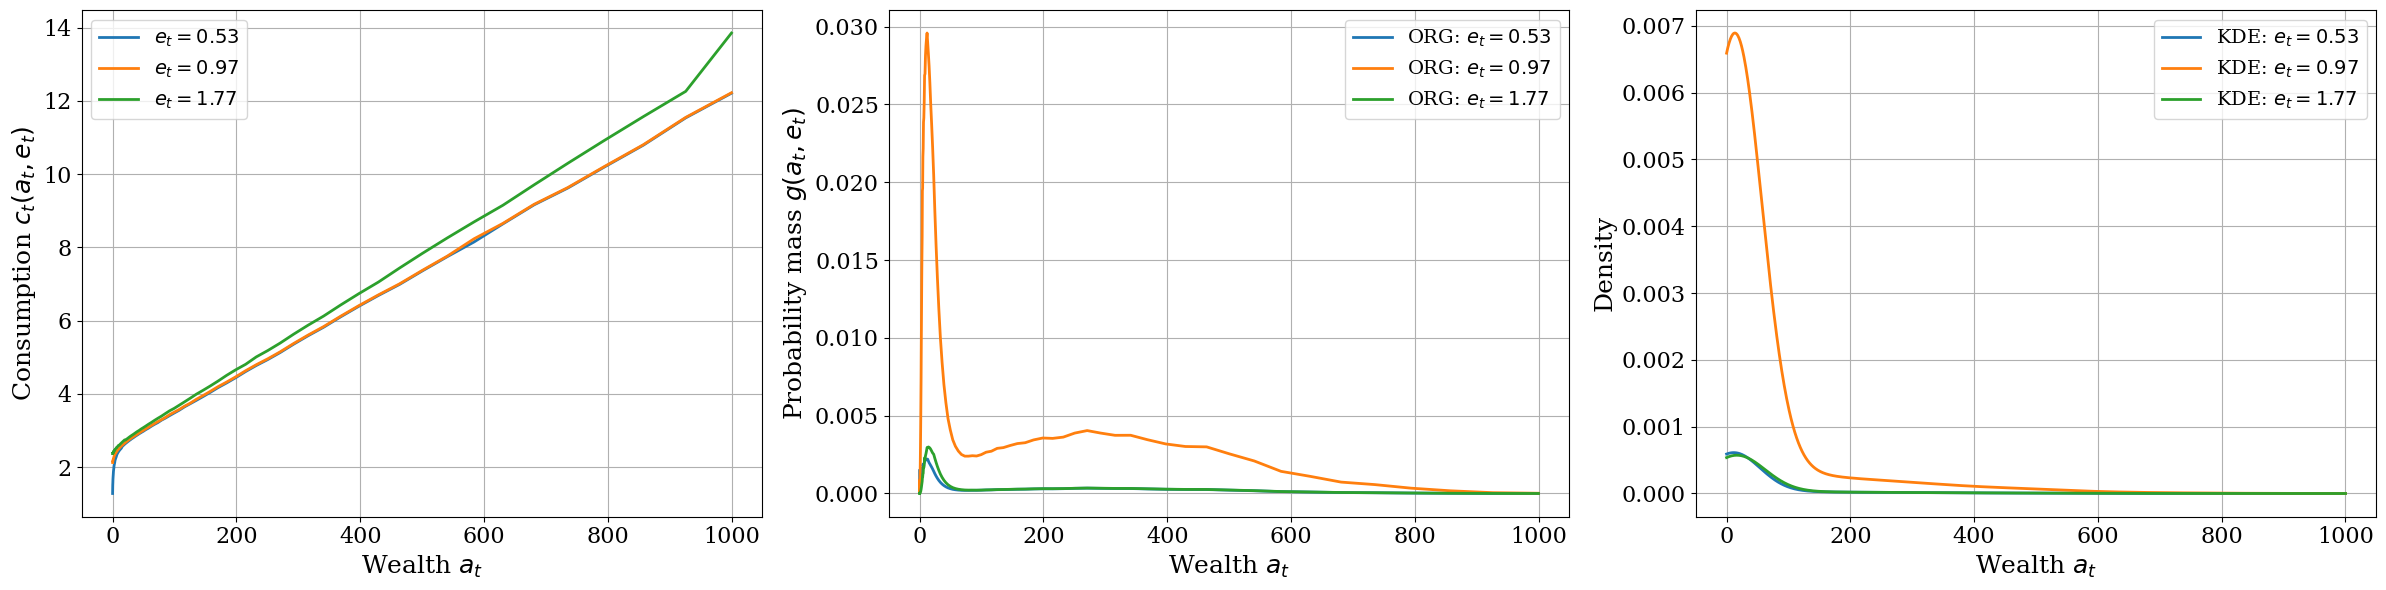

In [ ]:
fig,axs = create_subplots(1,3)
# Figure 1: Optimal policy function
ax = axs[0][0]
max_plot_a = a_max
idxx = jnp.where(a_grid<=max_plot_a)[0]
for eidx in range(ne):
    ax.plot(a_grid[idxx], opt_c[:,eidx][idxx], label=f"$e_t={e_grid[eidx]:.2f}$")
ax.set_xlabel("Wealth $a_t$")
ax.set_ylabel("Consumption $c_t(a_t,e_t)$")
ax.legend()
ax.grid(True)
# Figure 2: Stationary wealth distribution
ax = axs[0][1]
for eidx in range(ne):
    # plot original points
    ax.plot(a_grid[idxx], g[idxx,eidx], label=f'ORG: $e_t={e_grid[eidx]:.2f}$')
ax.set_xlabel("Wealth $a_t$")
ax.set_ylabel("Probability mass $g(a_t,e_t)$")
ax.legend()
ax.grid(True)
# Figure 3: Stationary wealth distribution KDE estimate
ax = axs[0][2]
for eidx in range(ne):
    kde = gaussian_kde(a_grid, weights=g[:,eidx])
    x_smooth = np.linspace(a_min, max_plot_a, 1000)
    y_smooth = kde(x_smooth) * g[:,eidx].sum()
    ax.plot(x_smooth, y_smooth, label=f'KDE: $e_t={e_grid[eidx]:.2f}$')
ax.set_xlabel("Wealth $a_t$")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True)

fig.tight_layout()
fig.savefig("./figures/ks98_steady_state_results.pdf")